In [3]:
!pip -q install numpy pandas scikit-learn matplotlib torch torchvision
!pip install --upgrade imbalanced-learn


[notice] A new release of pip is available: 23.3.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.3.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# @title Imports & utilities
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
import os, glob, math, json, random, time, itertools
from pathlib import Path
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA

# reproducibility
def set_seed(seed=47):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(47)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [5]:
# @title Config (edit here)
config = {
  "data_root": "/kaggle/input/nsl-kdd",  # Đường dẫn tới thư mục dataset
  "train_file": "/kaggle/input/nsl-kdd/NSL-KDD-Dataset-master/KDDTrain+.txt",  # File train cụ thể
  "test_file": "/kaggle/input/nsl-kdd/NSL-KDD-Dataset-master/KDDTest+.txt",    # File test cụ thể
  "dataset": "NSL-KDD",  # Cố định dataset là NSL-KDD
  "label_granularity": "attack_cat",  # Cố định phân loại đa lớp
  "window_len": 2,
  "window_stride":1 ,
  "image_h": 11,
  "batch_size": 128,
  "epochs": 1000,
  "lr": 5e-4,
  "weight_decay": 1e-4,
  "use_focal": True,
  "focal_gamma": 2.0,
  "class_weighting": True,
  "use_weighted_sampler": True,
  "use_adasyn": True,  
  "adasyn_n_neighbors": 3,
  "adasyn_sampling_strategy": "auto",
  "window_preserve_rare_classes": True,  
  "window_rare_classes": ['U2R'],             
  "adv_training": True,
  "adv_ratio": 0.5,
  "adv_attack": "fgsm",
  "epsilon": 0.02,#.01 – 0.1 (thường chọn 0.03 hoặc 0.05 trên dữ liệu chuẩn hóa).
  "pgd_steps":10, #số bước tấn công k = 10–40, step size = ε/k.
  "pgd_alpha": 0.01,
"eps_1d": 0.03,
 "eps_2d": 0.03,
 "pgd_steps_train": 10,
 "gaussian_sigma": 0.03,
 "grad_clip": 1.0,
 "amp": True,
 "scheduler": "onecycle",
  "save_dir": "/kaggle/working/"  # Local save directory
}
import os, json
os.makedirs(config["save_dir"], exist_ok=True)
print("Dataset: NSL-KDD với phân loại đa lớp (attack_cat)")
print(f"Train file: {config['train_file']}")
print(f"Test file: {config['test_file']}")
print(json.dumps(config, indent=2))

Dataset: NSL-KDD với phân loại đa lớp (attack_cat)
Train file: /kaggle/input/nsl-kdd/NSL-KDD-Dataset-master/KDDTrain+.txt
Test file: /kaggle/input/nsl-kdd/NSL-KDD-Dataset-master/KDDTest+.txt
{
  "data_root": "/kaggle/input/nsl-kdd",
  "train_file": "/kaggle/input/nsl-kdd/NSL-KDD-Dataset-master/KDDTrain+.txt",
  "test_file": "/kaggle/input/nsl-kdd/NSL-KDD-Dataset-master/KDDTest+.txt",
  "dataset": "NSL-KDD",
  "label_granularity": "attack_cat",
  "window_len": 2,
  "window_stride": 1,
  "image_h": 11,
  "batch_size": 128,
  "epochs": 1000,
  "lr": 0.0005,
  "weight_decay": 0.0001,
  "use_focal": true,
  "focal_gamma": 2.0,
  "class_weighting": true,
  "use_weighted_sampler": true,
  "use_adasyn": true,
  "adasyn_n_neighbors": 3,
  "adasyn_sampling_strategy": "auto",
  "window_preserve_rare_classes": true,
  "window_rare_classes": [
    "U2R"
  ],
  "adv_training": true,
  "adv_ratio": 0.5,
  "adv_attack": "fgsm",
  "epsilon": 0.02,
  "pgd_steps": 10,
  "pgd_alpha": 0.01,
  "eps_1d": 0.0

In [6]:
# @title Kiểm tra file NSL-KDD
import os

train_file = config["train_file"]
test_file = config["test_file"]

print("Kiểm tra sự tồn tại của files NSL-KDD:")
print(f"Train file: {train_file}")
print(f"  Exists: {os.path.exists(train_file)}")

print(f"Test file: {test_file}")  
print(f"  Exists: {os.path.exists(test_file)}")

if os.path.exists(train_file) and os.path.exists(test_file):
    print("\n✅ Tất cả files cần thiết đã tồn tại!")
    
    # Kiểm tra kích thước file
    train_size = os.path.getsize(train_file) / (1024*1024)  # MB
    test_size = os.path.getsize(test_file) / (1024*1024)    # MB
    print(f"Train file size: {train_size:.2f} MB")
    print(f"Test file size: {test_size:.2f} MB")
else:
    print("\n❌ Một hoặc nhiều file không tồn tại!")
    print("Vui lòng kiểm tra đường dẫn file.")

Kiểm tra sự tồn tại của files NSL-KDD:
Train file: /kaggle/input/nsl-kdd/NSL-KDD-Dataset-master/KDDTrain+.txt
  Exists: False
Test file: /kaggle/input/nsl-kdd/NSL-KDD-Dataset-master/KDDTest+.txt
  Exists: False

❌ Một hoặc nhiều file không tồn tại!
Vui lòng kiểm tra đường dẫn file.


In [7]:
# @title Data loading utilities
def load_any(f: str) -> pd.DataFrame:
    """Load file tùy theo extension"""
    ext = Path(f).suffix.lower()
    if ext in (".csv",".txt"):
        return pd.read_csv(f, header=None)
    if ext in (".parquet",".pq"):
        return pd.read_parquet(f)
    raise ValueError(f"Unsupported format: {ext}")



In [8]:
# @title Dataset parser (NSL-KDD only)
NSL_CAT = ["protocol_type", "service", "flag"]

def load_nsl_kdd_file(file_path: str) -> pd.DataFrame:
    """Load và xử lý 1 file NSL-KDD"""
    base_cols = [
        "duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment",
        "urgent","hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted",
        "num_root","num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login",
        "is_guest_login","count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
        "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
        "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
        "dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
        "label","difficulty"
    ]
    
    print(f"Đang load file: {file_path}")
    df = pd.read_csv(file_path, header=None)
    
    if df.shape[1] in (42, 43):
        df.columns = base_cols[:df.shape[1]]
    else:
        print(f"  Warning: Unexpected number of columns: {df.shape[1]}")
    
    # Xóa cột num_outbound_cmds (thường có giá trị 0 và không hữu ích)
    df.drop(columns=["num_outbound_cmds"], inplace=True)
    print(f"  Đã xóa cột 'num_outbound_cmds'")

    print(f"  Shape: {df.shape}")

    # Định nghĩa các nhóm tấn công cho NSL-KDD
    # Định nghĩa các nhóm tấn công cho NSL-KDD
    dos = {'apache2','mailbomb','back','land','neptune','pod','processtable','smurf','teardrop','udpstorm','worm'}
    
    probe = {'ipsweep','mscan','nmap','portsweep','saint','satan'}
    
    r2l = {'httptunnel','ftp_write','xlock','guess_passwd','http_tunnel','imap','multihop','named','phf','sendmail','snmpgetattack','snmpguess','spy','warezclient','warezmaster','xclock','xsnoop'}
    u2r = {'buffer_overflow','loadmodule','perl','ps','rootkit','sqlattack','xterm'}

    def map_cat(lbl):
        l = str(lbl).strip()
        if l == "normal": return "Benign"
        if l in dos: return "DoS"
        if l in probe: return "Probe"
        if l in r2l: return "R2L"
        if l in u2r: return "U2R"
        return l

    # Tạo nhãn phân loại đa lớp (attack_cat) 
    df["attack_cat"] = df["label"].apply(map_cat)
    return df

def load_train_test_separately():
    """Load riêng biệt train file và test file"""
    train_file = config["train_file"]
    test_file = config["test_file"]
    
    # Kiểm tra files tồn tại
    for f in [train_file, test_file]:
        if not os.path.exists(f):
            raise FileNotFoundError(f"File không tồn tại: {f}")
    
    print("Load train và test files riêng biệt:")
    train_df = load_nsl_kdd_file(train_file)
    test_df = load_nsl_kdd_file(test_file)
    
    return train_df, test_df

In [9]:
# @title Preprocessing: select features, encode categoricals, standardize numerics (NSL-KDD only)
def build_preprocessor(df: pd.DataFrame):
    """Xây dựng preprocessor cho NSL-KDD với phân loại đa lớp (attack_cat)"""
    y_col = "attack_cat"  # Cố định sử dụng phân loại đa lớp
    y = df[y_col].astype(str)

    # Loại bỏ các cột không cần thiết
    drop_cols = {c for c in df.columns if c.lower() in ("label","difficulty","binary","attack_cat","id","flow_id")}

    # Các cột categorical cho NSL-KDD
    cat_candidates = [c for c in NSL_CAT if c in df.columns]

    feat_cols = [c for c in df.columns if c not in drop_cols]
    num_cols  = [c for c in feat_cols if pd.api.types.is_numeric_dtype(df[c])]
    cat_cols  = [c for c in feat_cols if c in cat_candidates]



    X = df[feat_cols].copy()

    # Tạo preprocessor với StandardScaler cho numeric và OneHotEncoder cho categorical
    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)  # sklearn>=1.4
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)         # sklearn<=1.3

    pre = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(with_mean=True, with_std=True), num_cols),
            ("cat", ohe, cat_cols),
        ]
    )
    
    return pre, X, y, num_cols, cat_cols

def fit_transform(pre, Xtr, Xte):
    """Fit preprocessor trên train set và transform tất cả sets"""
    Xt = pre.fit_transform(Xtr)
    Xt2 = pre.transform(Xte)
    print("  Shape sau preprocessing:", Xt.shape, Xt2.shape)
    # Lấy tên features sau khi preprocessing
    num_names = pre.named_transformers_["num"].get_feature_names_out() if hasattr(pre.named_transformers_["num"], "get_feature_names_out") else np.array(pre.transformers_[0][2])
    try:
        cat_names = pre.named_transformers_["cat"].get_feature_names_out()  # sklearn>=1.0
    except Exception:
        cat_names = np.array(["cat_"+str(i) for i in range(len(pre.transformers_[1][1].categories_[0]) if len(pre.transformers_[1][1].categories_) > 0 else 0)])
    
    feat_names = np.concatenate([num_names, cat_names]) if len(cat_names) else num_names
    return Xt, Xt2, feat_names

In [10]:
import numpy as np

# --- Resize square matrix nhanh hơn ---
def _resize_square(mat: np.ndarray, target: int):
    n = mat.shape[0]
    if n == target:
        return mat
    if n > target:
        # nếu chia hết, dùng reshape + mean nhanh hơn vòng for
        if n % target == 0:
            factor = n // target
            return mat.reshape(target, factor, target, factor).mean(axis=(1,3))
        else:
            # fallback: dùng interpolation (cần skimage)
            from skimage.transform import resize
            return resize(mat, (target, target), anti_aliasing=True)
    else:
        # upsample bằng repeat + crop
        factor = int(np.ceil(target / n))
        up = np.repeat(np.repeat(mat, factor, axis=0), factor, axis=1)
        start = (up.shape[0] - target) // 2
        return up[start:start+target, start:start+target]

# --- Covariance -> Correlation ---
def _cov_to_corr(cov: np.ndarray, eps: float = 1e-12):
    d = np.sqrt(np.diag(cov))
    d[d < eps] = eps
    corr = cov / np.outer(d, d)
    corr = np.clip(corr, -1.0, 1.0)
    np.fill_diagonal(corr, 1.0)
    return np.nan_to_num(corr, nan=0.0, posinf=1.0, neginf=-1.0)

# --- Correlation matrix image ---
def create_correlation_matrix_image(
    x_win, target_size=(11, 11),
    method='pearson', pca_components=None,
    reorder=True, top_k=None, channels='single',
    shrinkage_estimator=None, eps=1e-10, random_state=42
):
    L, D = x_win.shape
    H, W = target_size

    # 1) Handle constant features
    feature_std = np.std(x_win, axis=0)
    constant_mask = feature_std < eps
    if np.all(constant_mask):
        out = np.zeros((H, W), dtype=np.float32)
        return out if channels == 'single' else np.stack([out]*3, axis=0)

    if np.any(constant_mask):
        rng = np.random.RandomState(random_state)
        x_win = x_win.copy()
        x_win[:, constant_mask] += rng.normal(scale=1e-8, size=(L, constant_mask.sum()))

    # 2) PCA reduction nếu cần
    reduced = None
    if pca_components is not None and D > pca_components:
        try:
            from sklearn.decomposition import TruncatedSVD
            reduced = TruncatedSVD(n_components=pca_components, random_state=random_state).fit_transform(x_win)
        except Exception:
            reduced = None

    data_for_corr = reduced if reduced is not None else x_win

    # 3) Compute correlation
    method_lower = method.lower()
    if method_lower == 'spearman':
        try:
            from scipy.stats import rankdata
            ranked = np.apply_along_axis(rankdata, 0, data_for_corr)
            corr_matrix = np.corrcoef(ranked, rowvar=False)
        except Exception:
            corr_matrix = np.corrcoef(data_for_corr.T)
    elif method_lower == 'shrinkage' or shrinkage_estimator == 'ledoit_wolf':
        try:
            from sklearn.covariance import LedoitWolf
            cov = LedoitWolf().fit(data_for_corr).covariance_
            corr_matrix = _cov_to_corr(cov)
        except Exception:
            corr_matrix = np.corrcoef(data_for_corr.T)
    else:
        corr_matrix = np.corrcoef(data_for_corr.T)

    corr_matrix = np.nan_to_num(corr_matrix, nan=0.0, posinf=1.0, neginf=-1.0)
    corr_matrix = np.clip(corr_matrix, -1.0, 1.0)
    np.fill_diagonal(corr_matrix, 1.0)

    # 4) Top-k sparsify
    sparse_bin = None
    if top_k is not None and top_k > 0 and corr_matrix.shape[0] > 1:
        abs_corr = np.abs(corr_matrix)
        mask = np.zeros_like(abs_corr)
        for i in range(abs_corr.shape[0]):
            idx_sort = np.argsort(abs_corr[i])[::-1][:top_k]
            mask[i, idx_sort] = 1.0
        mask = np.maximum(mask, mask.T)
        sparse_bin = (mask > 0).astype(float)

    # 5) Reorder bằng clustering
    order = np.arange(corr_matrix.shape[0])
    if reorder and corr_matrix.shape[0] > 2:
        try:
            from scipy.cluster.hierarchy import linkage, leaves_list
            from scipy.spatial.distance import squareform
            dist = 1.0 - np.abs(corr_matrix)
            condensed = squareform(dist, checks=False)
            order = leaves_list(linkage(condensed, method='average'))
        except Exception:
            pass

    corr_ord = corr_matrix[np.ix_(order, order)]
    abs_corr_ord = np.abs(corr_ord)
    sparse_ord = None if sparse_bin is None else sparse_bin[np.ix_(order, order)]

    # 6) Resize
    corr_final = _resize_square(corr_ord, H).astype(np.float32)
    abs_final = _resize_square(abs_corr_ord, H).astype(np.float32)
    sparse_final = None if sparse_ord is None else _resize_square(sparse_ord, H).astype(np.float32)

    if channels == 'single':
        return corr_final
    else:
        c1 = (corr_final + 1.0) / 2.0  # map [-1,1] -> [0,1]
        c2 = abs_final
        c3 = sparse_final if sparse_final is not None else np.zeros_like(c1)
        return np.stack([c1, c2, c3], axis=0)

# --- Build windows (bỏ pad channel) ---
def build_windows(
    X, y, window_len, stride, image_h,
    preserve_rare_classes=True, rare_classes=['U2R'],
    image_type='correlation',
    corr_params=None, gaf_params=None
):
    if corr_params is None: corr_params = {}
    if gaf_params is None: gaf_params = {}

    N, D = X.shape
    xs_1d, xs_2d, ys = [], [], []
    H = image_h

    for start in range(0, N - window_len + 1, stride):
        end = start + window_len
        x_win = X[start:end]
        y_win = y[start:end]

        x1d = x_win.T.astype(np.float32)

        if image_type == 'correlation':
            x2d = create_correlation_matrix_image(x_win, target_size=(H, H), **corr_params)
        elif image_type == 'gramian':
            x2d = create_gramian_angular_field(x_win, target_size=(H, H), **gaf_params)
        else:
            x_mean = x_win.mean(axis=0)
            pad = H*H - x_mean.size
            if pad > 0:
                x_mean = np.concatenate([x_mean, np.zeros(pad)], axis=0)
            x2d = x_mean.reshape(H, H).astype(np.float32)

        if x2d.ndim == 2:
            x2d = x2d[None, ...]  # (1,H,W)

        vals, counts = np.unique(y_win, return_counts=True)
        if preserve_rare_classes:
            y_major = vals[np.argmax(counts)]
            for rare_cls in rare_classes:
                if rare_cls in vals:
                    y_major = rare_cls
                    break
        else:
            y_major = vals[np.argmax(counts)]

        xs_1d.append(x1d)
        xs_2d.append(x2d.astype(np.float32))
        ys.append(y_major)

    xs_1d = np.stack(xs_1d, axis=0)   # (Nw,D,L)
    xs_2d = np.stack(xs_2d, axis=0)   # (Nw,C,H,W)
    ys = np.array(ys)

    return xs_1d, xs_2d, ys


In [11]:
# @title Torch Dataset
class DualViewDataset(Dataset):
    def __init__(self, x1d, x2d, y, label_to_id: Dict[str,int]):
        self.x1d = torch.from_numpy(x1d)            # (N, D, L)
        self.x2d = torch.from_numpy(x2d)            # (N, 1, H, W)
        self.y = torch.tensor([label_to_id[str(v)] for v in y], dtype=torch.long)
    def __len__(self): return self.x1d.shape[0]
    def __getitem__(self, idx):
        return self.x1d[idx], self.x2d[idx], self.y[idx]

In [12]:
class CNN1D(nn.Module):
    def __init__(self, in_channels: int, out_dim: int = 96):
        super().__init__()
        # Enhanced 1D branch với deeper architecture và residual connections
        self.conv1 = nn.Conv1d(in_channels, 96, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(96)
        self.conv2 = nn.Conv1d(96, 192, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(192)
        self.conv3 = nn.Conv1d(192, 384, kernel_size=3, padding=1)  # Thêm layer thứ 3
        self.bn3 = nn.BatchNorm1d(384)
        
        # Residual connection
        self.shortcut = nn.Conv1d(in_channels, 384, kernel_size=1)
        self.bn_shortcut = nn.BatchNorm1d(384)
        
        self.dropout = nn.Dropout(0.3)  # Giảm dropout
        self.fc = nn.Linear(384, out_dim)
        
    def forward(self, x):                # x: (B, C=in_channels, L)
        identity = x
        
        # Main path
        h = F.relu(self.bn1(self.conv1(x)))
        if h.size(-1) > 1:
            h = F.max_pool1d(h, 2)
        h = F.relu(self.bn2(self.conv2(h)))
        h = F.relu(self.bn3(self.conv3(h)))
        
        # Residual connection
        identity = self.bn_shortcut(self.shortcut(identity))
        identity = F.adaptive_max_pool1d(identity, h.size(-1))
        
        h = h + identity  # Residual connection
        h = F.adaptive_max_pool1d(h, 1).squeeze(-1)  # (B, 512)
        h = self.dropout(h)
        return self.fc(h)                # (B, out_dim)

class CNN2D(nn.Module):
    def __init__(self, out_dim: int = 96):
        super().__init__()
        # Main path
        self.conv1 = nn.Conv2d(1, 48, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(48)
        self.conv2 = nn.Conv2d(48, 96, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(96)
        self.conv3 = nn.Conv2d(96, 192, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(192)
        self.conv4 = nn.Conv2d(192, 384, 3, padding=1)  # thêm layer sâu
        self.bn4 = nn.BatchNorm2d(384)

        # Residual (shortcut) path
        self.shortcut = nn.Conv2d(1, 384, kernel_size=1)  # map từ 1 channel → 512 channel
        self.bn_shortcut = nn.BatchNorm2d(384)

        self.dropout = nn.Dropout(0.2)  # Giảm dropout
        self.fc = nn.Linear(384, out_dim)

    def forward(self, x):                 # x: (B, 1, H, W)
        identity = x

        # Main path
        h = F.relu(self.bn1(self.conv1(x)))
        if h.size(-1) > 1:
            h = F.max_pool2d(h, 2)
        h = F.relu(self.bn2(self.conv2(h)))
        # if h.size(-1) > 1:
        #     h = F.max_pool2d(h, 2)
        h = F.relu(self.bn3(self.conv3(h)))
        h = F.relu(self.bn4(self.conv4(h)))

        # Residual
        identity = self.bn_shortcut(self.shortcut(identity))
        identity = F.adaptive_max_pool2d(identity, h.shape[-2:])  # resize to match h

        # Add residual
        h = h + identity

        # Global pooling
        h = F.adaptive_max_pool2d(h, 1).squeeze(-1).squeeze(-1)  # (B, 512)
        h = self.dropout(h)
        return self.fc(h)                  # (B, out_dim)

class AttentionFusion(nn.Module):
    """Attention-based feature fusion thay vì simple concatenation"""
    def __init__(self, feature_dim: int = 96):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(feature_dim * 2, feature_dim),
            nn.Tanh(),
            nn.Linear(feature_dim, 2),
            nn.Softmax(dim=-1)
        )
        self.fc = nn.Linear(feature_dim * 2, feature_dim)
        
    def forward(self, h1, h2):
        # h1, h2: (B, feature_dim)
        concat_features = torch.cat([h1, h2], dim=-1)  # (B, feature_dim*2)
        attention_weights = self.attention(concat_features)  # (B, 2)
        
        # Apply attention weights
        weighted_h1 = h1 * attention_weights[:, 0:1]
        weighted_h2 = h2 * attention_weights[:, 1:2]
        
        # Combine weighted features
        fused = torch.cat([weighted_h1, weighted_h2], dim=-1)
        return self.fc(fused)  # (B, feature_dim)

class DVRCNN(nn.Module):
    def __init__(self, d_in: int, n_classes: int):
        super().__init__()
        self.branch1d = CNN1D(in_channels=d_in, out_dim=96)
        self.branch2d = CNN2D(out_dim=96)
        
        # Enhanced fusion với attention mechanism
        self.fusion = AttentionFusion(feature_dim=96)
        
        # Enhanced classifier với GELU, giảm dropout (Note: Trong training, dùng optimizer với weight_decay=0.01 cho L2 reg)
        self.classifier = nn.Sequential(
            nn.Linear(96, 192),
            nn.BatchNorm1d(192),
            nn.GELU(),  # Thay ReLU bằng GELU
            nn.Dropout(0.3),  # Giảm dropout
            nn.Linear(192, 96),
            nn.BatchNorm1d(96),
            nn.GELU(),
            nn.Dropout(0.2),  # Giảm dropout
            nn.Linear(96, n_classes),
        )
        
    def forward(self, x1d, x2d):
        h1 = self.branch1d(x1d)  # (B, 128)
        h2 = self.branch2d(x2d)  # (B, 128)
        h_fused = self.fusion(h1, h2)  # (B, 128)

        return self.classifier(h_fused)

In [13]:
# @title Losses: CrossEntropy with weights / Focal
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.weight = weight; self.gamma = gamma; self.reduction = reduction
    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, weight=self.weight, reduction='none')
        pt = torch.exp(-ce)
        loss = ((1-pt)**self.gamma) * ce
        return loss.mean() if self.reduction=='mean' else loss.sum()

In [14]:
# @title Adversarial FGSM / PGD on standardized features
def clamp_like(x, lo, hi):
    return torch.max(torch.min(x, hi), lo)

def fgsm_attack(model, x1d, x2d, y, eps, mask=None, bounds=None):
    x1d_adv = x1d.clone().detach().requires_grad_(True)
    x2d_adv = x2d.clone().detach().requires_grad_(True)

    logits = model(x1d_adv, x2d_adv)
    loss = F.cross_entropy(logits, y)
    loss.backward()
    model.zero_grad()

    with torch.no_grad():
        if mask is not None:
            x1d_adv = x1d_adv + eps * x1d_adv.grad.sign() * mask[:, :, None]
        else:
            x1d_adv = x1d_adv + eps * x1d_adv.grad.sign()
        x2d_adv = x2d_adv + eps * x2d_adv.grad.sign()

        if bounds is not None:
            lo1, hi1, lo2, hi2 = bounds
            x1d_adv = clamp_like(x1d_adv, lo1, hi1)
            x2d_adv = clamp_like(x2d_adv, lo2, hi2)

    return x1d_adv.detach(), x2d_adv.detach()

def pgd_attack(model, x1d, x2d, y, eps1, eps2, alpha1, alpha2, steps, mask=None, bounds=None, device='cuda'):
    # x1d,x2d: normalized tensors
    x1d_adv = x1d.clone().detach().to(device)
    x2d_adv = x2d.clone().detach().to(device)
    # random init within L-inf ball
    x1d_adv = x1d_adv + torch.empty_like(x1d_adv).uniform_(-eps1, eps1)
    x2d_adv = x2d_adv + torch.empty_like(x2d_adv).uniform_(-eps2, eps2)

    lo1, hi1, lo2, hi2 = bounds

    for _ in range(steps):
        x1d_adv.requires_grad_(True)
        x2d_adv.requires_grad_(True)

        logits = model(x1d_adv, x2d_adv)
        loss = F.cross_entropy(logits, y)
        model.zero_grad()
        if x1d_adv.grad is not None:
            x1d_adv.grad.detach_(); x1d_adv.grad.zero_()
        if x2d_adv.grad is not None:
            x2d_adv.grad.detach_(); x2d_adv.grad.zero_()
        loss.backward()

        with torch.no_grad():
            g1 = x1d_adv.grad.sign()
            g2 = x2d_adv.grad.sign()
            if mask is not None:
                x1d_adv = x1d_adv + alpha1 * g1 * mask[:, :, None]
            else:
                x1d_adv = x1d_adv + alpha1 * g1
            x2d_adv = x2d_adv + alpha2 * g2

            # project to L-inf ball around original x
            x1d_adv = torch.max(torch.min(x1d_adv, x1d + eps1), x1d - eps1)
            x2d_adv = torch.max(torch.min(x2d_adv, x2d + eps2), x2d - eps2)

            # clamp to data bounds
            x1d_adv = clamp_like(x1d_adv, lo1, hi1)
            x2d_adv = clamp_like(x2d_adv, lo2, hi2)

        x1d_adv = x1d_adv.detach()
        x2d_adv = x2d_adv.detach()
    return x1d_adv, x2d_adv

In [15]:
# @title Training and evaluation
def build_bounds(x1d_train, x2d_train):
    lo1 = x1d_train.amin(dim=(0,2), keepdim=True).to(device)
    hi1 = x1d_train.amax(dim=(0,2), keepdim=True).to(device)
    lo2 = x2d_train.amin(dim=0, keepdim=True).to(device)
    hi2 = x2d_train.amax(dim=0, keepdim=True).to(device)
    return (lo1, hi1, lo2, hi2)

@torch.no_grad()
def evaluate(model, loader, label_names):
    model.eval()
    all_y, all_p = [], []
    
    # Handle both regular loader and tqdm loader
    if hasattr(loader, '__iter__') and not hasattr(loader, 'dataset'):
        # This is a tqdm object
        iterator = loader
    else:
        # This is a regular DataLoader
        iterator = loader
        
    for x1d, x2d, y in iterator:
        x1d, x2d = x1d.to(device), x2d.to(device)
        logits = model(x1d, x2d)
        pred = logits.argmax(dim=-1).cpu().numpy()
        all_p.append(pred); all_y.append(y.numpy())
    y_true = np.concatenate(all_y); y_pred = np.concatenate(all_p)
    rep = classification_report(y_true, y_pred, target_names=label_names, digits=4, output_dict=True)
    return rep, y_true, y_pred

def plot_confmat(y_true, y_pred, label_names, title="Confusion matrix"):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(label_names))))
    fig, ax = plt.subplots(figsize=(6,6))
    im = ax.imshow(cm, interpolation='nearest')
    ax.set_title(title)
    ax.set_xticks(np.arange(len(label_names)))
    ax.set_yticks(np.arange(len(label_names)))
    ax.set_xticklabels(label_names, rotation=45, ha="right")
    ax.set_yticklabels(label_names)
    ax.set_ylabel("True"); ax.set_xlabel("Pred")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)
    fig.tight_layout()
    plt.show()

In [16]:
# @title Load NSL-KDD train và test files riêng biệt

print("Đang load NSL-KDD train và test files riêng biệt...")
print(f"Train file: {config['train_file']}")
print(f"Test file: {config['test_file']}")

train_df, test_df = load_train_test_separately()

print(f"\nTrain data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")

# Hiển thị thông tin phân bố các lớp trong train set
print("\nPhân bố attack categories trong TRAIN set:")
train_attack_counts = train_df["attack_cat"].value_counts()
print(train_attack_counts)

print("\nTỷ lệ phần trăm attack categories trong TRAIN set:")
for cat, count in train_attack_counts.items():
    pct = (count / len(train_df)) * 100
    print(f"  {cat}: {count:,} ({pct:.2f}%)")

# Hiển thị thông tin phân bố các lớp trong test set
print("\nPhân bố attack categories trong TEST set:")
test_attack_counts = test_df["attack_cat"].value_counts()
print(test_attack_counts)

print("\nTỷ lệ phần trăm attack categories trong TEST set:")
for cat, count in test_attack_counts.items():
    pct = (count / len(test_df)) * 100
    print(f"  {cat}: {count:,} ({pct:.2f}%)")

print(f"\nShape train : {train_df.shape}")
print(f"Shape test:{test_df.shape}")


Đang load NSL-KDD train và test files riêng biệt...
Train file: /kaggle/input/nsl-kdd/NSL-KDD-Dataset-master/KDDTrain+.txt
Test file: /kaggle/input/nsl-kdd/NSL-KDD-Dataset-master/KDDTest+.txt


FileNotFoundError: File không tồn tại: /kaggle/input/nsl-kdd/NSL-KDD-Dataset-master/KDDTrain+.txt

In [ ]:
# @title Split train thành train/validation, giữ nguyên test set gốc
y_col = "attack_cat"  # Cố định sử dụng phân loại đa lớp

print("Giữ nguyên test set gốc để đánh giá cuối cùng")

# Chỉ chia train_df thành train/validation, giữ nguyên test_df

print(f"Test set (giữ nguyên): {test_df.shape[0]} samples")

print("\nXây dựng preprocessor từ train set...")
pre, X_train_raw, y_train, num_cols, cat_cols = build_preprocessor(train_df)
X_test_raw, y_test = test_df[num_cols + cat_cols], test_df[y_col].astype(str)

print("Đang fit và transform features...")
Xtr, Xte, feat_names = fit_transform(pre, X_train_raw, X_test_raw)
print("Số features sau khi preprocessing:", len(feat_names))
print("Shape của các tập sau preprocessing:")
print(Xtr.shape, Xte.shape)
print("\nPhân bố lớp trong các tập:")
print("TRAIN set:")
print(y_train.value_counts())
print("\nTEST set (gốc):")
print(y_test.value_counts())

# ADASYN Oversampling (row-level) BEFORE windowing
if config["use_adasyn"]:
    from imblearn.over_sampling import ADASYN
    
    print("\n" + "="*60)
    print("APPLYING ADASYN TO TRAINING SET")
    print("="*60)
    
    print("Class distribution BEFORE ADASYN:")
    original_count = len(y_train)
    for cat, count in y_train.value_counts().items():
        pct = (count / len(y_train)) * 100
        print(f"  {cat}: {count:,} ({pct:.2f}%)")
    
    print(f"\nOriginal train set shape: {Xtr.shape}")
    
    # Apply ADASYN with config parameters
    # ADASYN tự động tập trung vào các vùng khó phân biệt (hard examples)
    adasyn = ADASYN(
        sampling_strategy=config["adasyn_sampling_strategy"],
        random_state=42,
        n_neighbors=config["adasyn_n_neighbors"],  # Ít neighbors hơn SMOTE để tập trung vào hard cases
    )
    
    print(f"Applying ADASYN with n_neighbors={config['adasyn_n_neighbors']}...")
    print("ADASYN focuses on hard-to-learn examples near decision boundaries...")
    print("This may take a few minutes for large datasets...")
    
    try:
        Xtr_adasyn, y_train_adasyn = adasyn.fit_resample(Xtr, y_train)
        
        # Convert back to pandas Series for y_train
        y_train = pd.Series(y_train_adasyn, name='attack_cat')
        Xtr = Xtr_adasyn
        
        print(f"✅ ADASYN completed successfully!")
        print(f"New train set shape: {Xtr.shape}")
        print(f"Added {Xtr.shape[0] - original_count:,} synthetic samples")
        
        print("\nClass distribution AFTER ADASYN:")
        for cat, count in y_train.value_counts().items():
            pct = (count / len(y_train)) * 100
            print(f"  {cat}: {count:,} ({pct:.2f}%)")
        

        
    except Exception as e:
        print(f"❌ ADASYN failed: {e}")

    
    print("="*60)
    print("ADASYN COMPLETED - TRAINING SET ADAPTIVELY BALANCED")
    print("="*60)
    
else:
    print("\nADASYN disabled in config - skipping oversampling")

# Gán lại biến train_df để tương thích với code sau

Giữ nguyên test set gốc để đánh giá cuối cùng
Test set (giữ nguyên): 22544 samples

Xây dựng preprocessor từ train set...
Đang fit và transform features...
  Shape sau preprocessing: (125973, 121) (22544, 121)
Số features sau khi preprocessing: 121
Shape của các tập sau preprocessing:
(125973, 121) (22544, 121)

Phân bố lớp trong các tập:
TRAIN set:
attack_cat
Benign    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

TEST set (gốc):
attack_cat
Benign    9711
DoS       7460
R2L       2885
Probe     2421
U2R         67
Name: count, dtype: int64

APPLYING ADASYN TO TRAINING SET
Class distribution BEFORE ADASYN:
  Benign: 67,343 (53.46%)
  DoS: 45,927 (36.46%)
  Probe: 11,656 (9.25%)
  R2L: 995 (0.79%)
  U2R: 52 (0.04%)

Original train set shape: (125973, 121)
Applying ADASYN with n_neighbors=3...
ADASYN focuses on hard-to-learn examples near decision boundaries...
This may take a few minutes for large datasets...
✅ ADASYN completed successf

In [ ]:
print("="*60)
print("CREATING WINDOWS WITH OPTIMIZED STRATEGY")
print("="*60)

# STRATEGY EXPLANATION:
# - If SMOTE is used: Classes are already balanced, use majority vote
# - If SMOTE is disabled: Preserve rare classes (U2R, R2L) in windows

print(f"Window parameters:")
print(f"  Window length: {config['window_len']}")
print(f"  Window stride: {config['window_stride']}")
print(f"  Image height: {config['image_h']}")
print(f"  Preserve rare classes: {config['window_preserve_rare_classes']}")
print(f"  Rare classes: {config['window_rare_classes']}")

print(f"\nRebuilding windows...")

# Build windows với strategy dựa trên SMOTE usage
start_time = time.time()
X_tr, X_val, y_tr, y_val = train_test_split(
    Xtr, y_train, test_size=0.2, random_state=42)
print("  Processing train set...")
x1d_tr, x2d_tr, y_tr = build_windows(
    Xtr, y_train.values, config["window_len"], config["window_stride"], 
    config["image_h"], 
    preserve_rare_classes=config["window_preserve_rare_classes"], 
    rare_classes=config["window_rare_classes"],
    image_type='correlation'  # Sử dụng correlation matrix images
)

print("  Processing test set...")
x1d_te, x2d_te, y_te = build_windows(
    Xte, y_test.values, 1,1, 
    config["image_h"], 
    preserve_rare_classes=config["window_preserve_rare_classes"], 
    rare_classes=config["window_rare_classes"],
    image_type='correlation'
)
print("  Processing val set...")
x1d_val, x2d_val, y_val = build_windows(
    X_val, y_val.values, 1,1, 
    config["image_h"], 
    preserve_rare_classes=config["window_preserve_rare_classes"], 
    rare_classes=config["window_rare_classes"],
    image_type='correlation'
)

window_time = time.time() - start_time

print(f"\nWindow creation results:")
print(f"  Time taken: {window_time:.2f}s")
print(f"  Train windows: {x1d_tr.shape[0]:,}")
print(f"  Test windows: {x1d_te.shape[0]:,}")
print(f"  Total windows: {x1d_tr.shape[0] + x1d_te.shape[0]:,}")

print(f"\nWindow shapes:")
print(f"  1D shape: {x1d_tr.shape} (N, Features, Window_len)")
print(f"  2D shape: {x2d_tr.shape} (N, Channels, Height, Width)")

# Calculate 2D image dimensions
image_w = x2d_tr.shape[3]
print(f"  2D image size: {config['image_h']} x {image_w}")

# Labels processing
label_names = sorted(list(set(y_tr) | set(y_te)))
label_to_id = {l:i for i,l in enumerate(label_names)}

print(f"\nLabel mapping:")
for label, idx in label_to_id.items():
    print(f"  {idx}: {label}")

# Label distribution in windows
print(f"\nLabel distribution in windows:")
train_window_dist = pd.Series(y_tr).value_counts()
test_window_dist = pd.Series(y_te).value_counts()
val_window_dist = pd.Series(y_val).value_counts()
print(f"{'Label':<10} {'Train':<8} {'Val':<8} {'Test':<8} {'Total':<8}")
print("-" * 50)
for label in label_names:
    train_count = train_window_dist.get(label, 0)
    test_count = test_window_dist.get(label, 0)
    val_count= val_window_dist.get(label, 0)
    total_count = train_count  + test_count +val_count
    print(f"{label:<10} {train_count:<8}{val_count:<8}  {test_count:<8} {total_count:<8}")

# Kiểm tra U2R
has_u2r = 'U2R' in label_names
print(f"\nChecking U2R:")
if has_u2r:
    u2r_total = train_window_dist.get('U2R', 0)  + test_window_dist.get('U2R', 0)
    print(f"SUCCESS! U2R appeared: {u2r_total} windows")
    print(f"Classes found: {len(label_names)} - {label_names}")
else:
    print(f"U2R still missing")
    print(f"Classes found: {len(label_names)} - {label_names}")

# Create PyTorch datasets
print(f"\nCreating PyTorch datasets...")
ds_tr = DualViewDataset(x1d_tr, x2d_tr, y_tr, label_to_id)
ds_te = DualViewDataset(x1d_te, x2d_te, y_te, label_to_id)
ds_val = DualViewDataset(x1d_val, x2d_val, y_val, label_to_id)

# Weighted sampler setup
sampler = None
if config["use_weighted_sampler"]:
    print(f"  Setting up weighted sampler...")
    counts = np.bincount(ds_tr.y.numpy(), minlength=len(label_names))
    inv = 1.0 / np.maximum(counts, 1)
    weights = inv[ds_tr.y.numpy()]
    sampler = WeightedRandomSampler(weights=weights, num_samples=len(weights), replacement=True)
    
    print(f"  Class weights for sampling:")
    for i, (name, weight) in enumerate(zip(label_names, inv)):
        class_count = counts[i]
        print(f"    {name}: count={class_count}, weight={weight:.4f}")

# Create data loaders
print(f"\nCreating data loaders...")
# Set pin_memory=False when using CPU to avoid warnings
use_pin_memory = device.type == 'cuda'
train_loader = DataLoader(ds_tr, batch_size=config["batch_size"], shuffle=(sampler is None), sampler=sampler, num_workers=0, pin_memory=use_pin_memory)
test_loader = DataLoader(ds_te, batch_size=config["batch_size"], shuffle=False, num_workers=0, pin_memory=use_pin_memory)
val_loader = DataLoader(ds_val, batch_size=config["batch_size"], shuffle=False, num_workers=0, pin_memory=use_pin_memory)

print(f"  Train loader: {len(train_loader)} batches")
print(f"  Test loader: {len(test_loader)} batches")
print(f"  Val loader: {len(val_loader)} batches")

print(f"  Batch size: {config['batch_size']}")
print(f"  Shuffle: {sampler is None} (using sampler: {sampler is not None})")



CREATING WINDOWS WITH OPTIMIZED STRATEGY
Window parameters:
  Window length: 2
  Window stride: 1
  Image height: 11
  Preserve rare classes: True
  Rare classes: ['U2R']

Rebuilding windows...
  Processing train set...
  Processing test set...
  Processing val set...

Window creation results:
  Time taken: 601.35s
  Train windows: 336,621
  Test windows: 22,544
  Total windows: 359,165

Window shapes:
  1D shape: (336621, 121, 2) (N, Features, Window_len)
  2D shape: (336621, 1, 11, 11) (N, Channels, Height, Width)
  2D image size: 11 x 11

Label mapping:
  0: Benign
  1: DoS
  2: Probe
  3: R2L
  4: U2R

Label distribution in windows:
Label      Train    Val      Test     Total   
--------------------------------------------------
Benign     98623   13538     9711     121872  
DoS        47362   13430     7460     68252   
Probe      56900   13456     2421     72777   
R2L        66352   13527     2885     82764   
U2R        67384   13374     67       80825   

Checking U2R:
SUCCESS

In [ ]:
import os
print("="*60)
print("MODEL, LOSS, OPTIMIZER SETUP")
print("="*60)

# Model architecture
d_in = x1d_tr.shape[1]
n_classes = len(label_names)

checkpoint_path = "/kaggle/working/last_checkpoint.pt"

start_epoch = 0
best_acc = 0.0


if os.path.exists(checkpoint_path):
    print(f"=> Loading checkpoint from {checkpoint_path}")

    # Cho phép numpy scalar được unpickle (PyTorch >=2.6)
    torch.serialization.add_safe_globals([np.core.multiarray.scalar])

    # Load đầy đủ checkpoint (model, optimizer, scheduler, config, …)
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    model = DVRCNN(d_in=d_in, n_classes=len(checkpoint["label_names"])).to(device)
    model.load_state_dict(checkpoint["model"])

    # Optimizer + Scheduler
    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=checkpoint["config"]["lr"],
                                  weight_decay=checkpoint["config"]["weight_decay"])
    optimizer.load_state_dict(checkpoint["optimizer"])

    if "scheduler" in checkpoint:
        scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=5e-4,
                                                steps_per_epoch=len(train_loader),
                                                epochs=config['epochs'])
        scheduler.load_state_dict(checkpoint["scheduler"])
    else:
        scheduler = None

    # Restore các tham số khác
    label_names = checkpoint["label_names"]
    best_acc = checkpoint["best_acc"]
    start_epoch = checkpoint["epoch"]
    config = checkpoint["config"]

    print(f"  Resume from epoch {start_epoch}, best_acc={best_acc:.4f}")
    print(f"  Classes: {label_names}")




else:
    print("=> No checkpoint found, initializing new model.")

    model = DVRCNN(d_in=d_in, n_classes=n_classes).to(device)

    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=config["lr"],
                                  weight_decay=config["weight_decay"])

    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=5e-4,
                                                steps_per_epoch=len(train_loader),
                                                epochs=config['epochs'])
# Model architecture details
print(f"\nModel Components:")
print(f"  1D-CNN branch: {sum(p.numel() for p in model.branch1d.parameters()):,} params")
print(f"  2D-CNN branch: {sum(p.numel() for p in model.branch2d.parameters()):,} params") 
print(f"  Classifier: {sum(p.numel() for p in model.classifier.parameters()):,} params")

# Class weights setup
cls_weights = None
if config["class_weighting"]:
    print(f"\nSetting up class weights...")
    counts = np.bincount(ds_tr.y.numpy(), minlength=n_classes)
    freq = counts / counts.sum()
    w = 1.0 / np.maximum(freq, 1e-6)
    w = w / w.mean()
    w = list(w)
    for i,name in enumerate(label_names):
        if name =="U2R":
            w[i]*=8
        elif name =="R2L":
            w[i]*=4
        elif name =="Benign":
            w[i]*=0.8
        elif name =="DoS":
            w[i]*=1
        elif name =="Probe":
            w[i]*=1
            
    cls_weights = torch.tensor(w, dtype=torch.float32, device=device)
    
    print(f"  Class frequencies:")
    for i, (name, weight) in enumerate(zip(label_names, cls_weights.cpu().numpy())):
        print(f"    {name}: freq={freq[i]:.4f}, weight={weight:.4f}")

# Loss function
print(f"\nLoss Function:")
if config["use_focal"]:
    loss_fn = FocalLoss(weight=cls_weights, gamma=config["focal_gamma"])
    print(f"  Focal Loss (gamma={config['focal_gamma']})")
else:
    loss_fn = nn.CrossEntropyLoss(weight=cls_weights)
    print(f"  Cross Entropy Loss")

if cls_weights is not None:
    print(f"  Using class weights: {config['class_weighting']}")
else:
    print(f"  No class weights")
# Adversarial training setup
print(f"\nAdversarial Training Setup:")
d_num = len(num_cols)
mask_1d = torch.zeros((1, d_in), dtype=torch.float32, device=device)
mask_1d[:, :d_num] = 1.0

print(f"  Enabled: {config['adv_training']}")
if config['adv_training']:
    print(f"  Attack type: {config['adv_attack'].upper()}")
    print(f"  Epsilon: {config['epsilon']}")
    print(f"  PGD steps: {config['pgd_steps']}")
    print(f"  PGD alpha: {config['pgd_alpha']}")
    print(f"  Numeric features mask: {d_num}/{d_in} features")

# Build bounds for adversarial training
print(f"\nBuilding feature bounds...")
with torch.no_grad():
    sample_size = min(len(ds_tr), 2048)
    x1d_stack = torch.cat([b[0].unsqueeze(0) for b in itertools.islice(ds_tr, 0, sample_size)], dim=0).to(device)
    x2d_stack = torch.cat([b[1].unsqueeze(0) for b in itertools.islice(ds_tr, 0, sample_size)], dim=0).to(device)
bounds = build_bounds(x1d_stack, x2d_stack)

print(f"  Computed bounds from {sample_size} samples")
print(f"  1D bounds shape: {bounds[0].shape}, {bounds[1].shape}")
print(f"  2D bounds shape: {bounds[2].shape}, {bounds[3].shape}")

# Data loader info
print(f"\nData Loaders:")
print(f"  Train batches: {len(train_loader)} (batch_size={config['batch_size']})")
print(f"  Test batches: {len(test_loader)}")
print(f"  Val batches: {len(val_loader)}")

print(f"  Weighted sampler: {config['use_weighted_sampler']}")





MODEL, LOSS, OPTIMIZER SETUP
=> No checkpoint found, initializing new model.

Model Components:
  1D-CNN branch: 397,920 params
  2D-CNN branch: 912,000 params
  Classifier: 38,213 params

Setting up class weights...
  Class frequencies:
    Benign: freq=0.2930, weight=0.5151
    DoS: freq=0.1407, weight=1.3407
    Probe: freq=0.1690, weight=1.1160
    R2L: freq=0.1971, weight=3.8281
    U2R: freq=0.2002, weight=7.5389

Loss Function:
  Focal Loss (gamma=2.0)
  Using class weights: True

Adversarial Training Setup:
  Enabled: True
  Attack type: FGSM
  Epsilon: 0.02
  PGD steps: 10
  PGD alpha: 0.01
  Numeric features mask: 37/121 features

Building feature bounds...
  Computed bounds from 2048 samples
  1D bounds shape: torch.Size([1, 121, 1]), torch.Size([1, 121, 1])
  2D bounds shape: torch.Size([1, 1, 11, 11]), torch.Size([1, 1, 11, 11])

Data Loaders:
  Train batches: 2630 (batch_size=128)
  Test batches: 177
  Val batches: 526
  Weighted sampler: True


In [ ]:
# @title Training Loop - NSL-KDD Multi-class Classification (with LR scheduler and early stopping)
from tqdm.auto import tqdm
import time
from datetime import datetime

# Early stopping and LR scheduler params
patience = 50  
wait = 0 
best_path = os.path.join("/kaggle/working/","best_nsl_kdd_multiclass.pt")
print("="*60)
print("STARTING NSL-KDD MULTI-CLASS TRAINING")
print("="*60)
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Model will be saved at: {best_path}")
print(f"Number of classes: {len(label_names)} - {label_names}")
print(f"Train batches: {len(train_loader)}")
print(f"Device: {device} | Batch size: {config['batch_size']} | LR: {config['lr']}")
print(f"Epochs: {config['epochs']} | Adversarial training: {config['adv_training']}")
print(f"Patience: {patience}")
if config['adv_training']:
    print(f"Attack: {config['adv_attack'].upper()} | Epsilon: {config['epsilon']}")
print("-"*60)

train_start_time = time.time()



for epoch in range(start_epoch+1, config["epochs"]+1):
    epoch_start = time.time()
    model.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0   # thêm biến đếm accuracy train

    # ---------------- TRAIN ----------------
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{config['epochs']} [Train]", leave=False)

    for x1d, x2d, y in train_pbar:
        x1d, x2d, y = x1d.to(device), x2d.to(device), y.to(device)
        optimizer.zero_grad()

        if config["adv_training"]:
            if config["adv_attack"] == "pgd":
                eps1, eps2 = config['eps_1d'], config['eps_2d']
                steps = config['pgd_steps_train']
                alpha1 = eps1 / steps
                alpha2 = eps2 / steps
                adv_idx = torch.arange(y.size(0), device=device)
                x1d_adv, x2d_adv = pgd_attack(model,x1d[adv_idx].clone(),
                                                   x2d[adv_idx].clone(),
                                                   y[adv_idx],
                                                   eps1, eps2, alpha1, alpha2,
                                                   steps, mask=config.get('mask'), bounds=bounds, device=device)
                logits = model(x1d_adv, x2d_adv)
            else:
                epsilon_fgsm = config["epsilon"]
                x1d_adv, x2d_adv=fgsm_attack(model, x1d, x2d, y, epsilon_fgsm, mask=config.get('mask'), bounds=bounds)
                logits = model(x1d_adv, x2d_adv)
        else:
            logits = model(x1d, x2d)

        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # --------- tính train acc ----------
        preds = logits.argmax(dim=-1)
        correct_train += (preds == y).sum().item()
        total_train += y.size(0)

        train_pbar.set_postfix(loss=loss.item())

    avg_train_loss = running_loss / len(train_loader)
    train_acc = correct_train / total_train

    # ---------------- VALIDATION ----------------
    model.eval()
    all_y, all_p, val_loss = [], [], 0.0
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch}/{config['epochs']} [Val]", leave=False)

    with torch.no_grad():
        for x1d, x2d, y in val_pbar:
            x1d, x2d, y = x1d.to(device), x2d.to(device), y.to(device)
            logits = model(x1d, x2d)
            loss = loss_fn(logits, y)
            val_loss += loss.item()

            pred = logits.argmax(dim=-1).cpu().numpy()
            all_p.append(pred)
            all_y.append(y.cpu().numpy())

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_p)
    rep_v = classification_report(y_true, y_pred, target_names=label_names,
                                  digits=4, output_dict=True)

    macro_f1 = rep_v["macro avg"]["f1-score"]
    weighted_f1 = rep_v["weighted avg"]["f1-score"]
    accuracy = rep_v["accuracy"]
    avg_val_loss = val_loss / len(test_loader)

    # ---------------- LOG & SAVE ----------------
    epoch_time = time.time() - epoch_start
    tqdm.write(f"EPOCH {epoch}/{config['epochs']} | "
               f"Train Loss: {avg_train_loss:.4f} | "
               f"Train Acc: {train_acc:.4f} | "    
               f"Val Loss: {avg_val_loss:.4f} | "
               f"Val Acc: {accuracy:.4f} | "
               f"Macro F1: {macro_f1:.4f} | "
               f"Time: {epoch_time:.1f}s")
    
    # Early stopping & LR scheduling
    torch.save({
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict() if scheduler else None,
            "epoch": epoch,
            "best_acc": best_acc,
            "label_names": label_names,
            "config": config
        }, "/kaggle/working/last_checkpoint.pt")
    if accuracy > best_acc:
        wait = 0
        rep_te, yt, yp = evaluate(model, test_loader, label_names)
        # In classification report
        print("\nCLASSIFICATION REPORT:")
        print(classification_report(yt, yp, target_names=label_names, digits=4))
        # Save best model
        best_acc = accuracy
        torch.save({
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict() if scheduler else None,
            "epoch": epoch,
            "best_acc": best_acc,
            "label_names": label_names,
            "config": config
        }, best_path)

        tqdm.write("  ✅ NEW BEST MODEL SAVED!")
        tqdm.write(f"     Best accuracy: {accuracy:.4f}")
        tqdm.write("     Recall:")
        for class_name in label_names:
            if class_name in rep_v:
                tqdm.write(f"       {class_name}: {rep_v[class_name]['recall']:.4f}")
    else:
        wait +=1
        if wait >= patience:
            tqdm.write(f"No improvement for {patience}. Stopping training.")
            break


    # Scheduler step nếu có
    if scheduler is not None:
        scheduler.step()

print("="*60)
print(f"TRAINING COMPLETED! Best Accuracy: {best_acc:.4f}")
print(f"Model saved at: {best_path}")
print(f"Total training time: {(time.time()-train_start_time)/60:.1f} minutes")
print("="*60)

STARTING NSL-KDD MULTI-CLASS TRAINING
Start time: 2025-09-27 16:19:28
Model will be saved at: /kaggle/working/best_nsl_kdd_multiclass.pt
Number of classes: 5 - ['Benign', 'DoS', 'Probe', 'R2L', 'U2R']
Train batches: 2630
Device: cuda | Batch size: 128 | LR: 0.0005
Epochs: 1000 | Adversarial training: True
Patience: 50
Attack: FGSM | Epsilon: 0.02
------------------------------------------------------------


Epoch 1/1000 [Train]:   0%|          | 0/2630 [00:00<?, ?it/s]

Epoch 1/1000 [Val]:   0%|          | 0/526 [00:00<?, ?it/s]

EPOCH 1/1000 | Train Loss: 0.9842 | Train Acc: 0.7004 | Val Loss: 5.1320 | Val Acc: 0.6790 | Macro F1: 0.6501 | Time: 74.1s

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Benign     0.9759    0.1875    0.3146      9711
         DoS     0.8283    0.5529    0.6632      7460
       Probe     0.3359    0.8732    0.4852      2421
         R2L     0.2097    0.6267    0.3143      2885
         U2R     0.0459    0.5373    0.0845        67

    accuracy                         0.4393     22544
   macro avg     0.4791    0.5555    0.3724     22544
weighted avg     0.7575    0.4393    0.4475     22544

  ✅ NEW BEST MODEL SAVED!
     Best accuracy: 0.6790
     Recall:
       Benign: 0.1521
       DoS: 0.7601
       Probe: 0.9119
       R2L: 0.9415
       U2R: 0.6313


Epoch 2/1000 [Train]:   0%|          | 0/2630 [00:00<?, ?it/s]

...

Epoch 94/1000 [Val]:   0%|          | 0/526 [00:00<?, ?it/s]

EPOCH 94/1000 | Train Loss: 0.0207 | Train Acc: 0.9873 | Val Loss: 15.3364 | Val Acc: 0.6979 | Macro F1: 0.6847 | Time: 77.2s


Epoch 95/1000 [Train]:   0%|          | 0/2630 [00:00<?, ?it/s]

Epoch 95/1000 [Val]:   0%|          | 0/526 [00:00<?, ?it/s]

EPOCH 95/1000 | Train Loss: 0.0167 | Train Acc: 0.9881 | Val Loss: 15.7532 | Val Acc: 0.7087 | Macro F1: 0.6963 | Time: 77.2s
No improvement for 50. Stopping training.
TRAINING COMPLETED! Best Accuracy: 0.8128
Model saved at: /kaggle/working/best_nsl_kdd_multiclass.pt
Total training time: 123.4 minutes


TEST SET EVALUATION (CLEAN)
Loading best model...

Running evaluation on test set...

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Benign     0.9404    0.8115    0.8712      9711
         DoS     0.8774    0.8625    0.8699      7460
       Probe     0.6913    0.8323    0.7552      2421
         R2L     0.5891    0.7733    0.6688      2885
         U2R     0.1846    0.3582    0.2437        67

    accuracy                         0.8243     22544
   macro avg     0.6566    0.7275    0.6817     22544
weighted avg     0.8456    0.8243    0.8305     22544



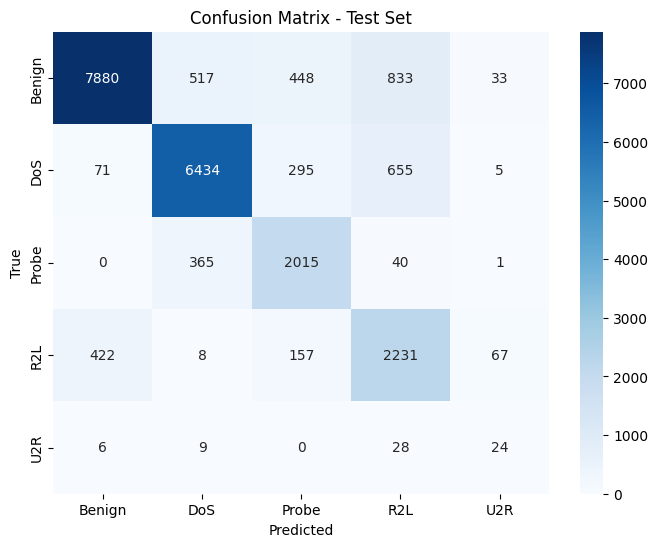

In [ ]:
# @title Evaluate trên test set (clean)
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("="*60)
print("TEST SET EVALUATION (CLEAN)")
print("="*60)

print("Loading best model...")
ckpt = torch.load(best_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model"])
label_names = ckpt["label_names"]

print("\nRunning evaluation on test set...")
rep_te, yt, yp = evaluate(model, test_loader, label_names)

# In classification_report
print("\nCLASSIFICATION REPORT:")
print(classification_report(yt, yp, target_names=label_names, digits=4))

# Vẽ confusion matrix
cm = confusion_matrix(yt, yp)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Test Set")
plt.show()


In [ ]:
# @title Hàm đánh giá chung cho các loại tấn công
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

@torch.no_grad()
def eval_fgsm_attack(model, loader, epsilon, mask=None, bounds=None):
    """Đánh giá mô hình dưới tấn công FGSM"""
    model.eval()
    all_y, all_p = [], []
    print(f"Đang thực hiện tấn công FGSM với epsilon={epsilon}")
    
    for x1d, x2d, y in loader:
        x1d, x2d, y = x1d.to(device), x2d.to(device), y.to(device)
        torch.set_grad_enabled(True)
        ax1d, ax2d = fgsm_attack(model, x1d, x2d, y, epsilon, mask, bounds)
        torch.set_grad_enabled(False)
        logits = model(ax1d, ax2d)
        pred = logits.argmax(dim=-1).cpu().numpy()
        all_p.append(pred); all_y.append(y.cpu().numpy())
    
    y_true = np.concatenate(all_y); y_pred = np.concatenate(all_p)
    return y_true, y_pred

@torch.no_grad()
def eval_pgd_attack(model, loader, epsilon1, epsilon2, alpha1, alpha2, steps, mask=None, bounds=None):
    """Đánh giá mô hình dưới tấn công PGD"""
    model.eval()
    all_y, all_p = [], []

    for x1d, x2d, y in loader:
        x1d, x2d, y = x1d.to(device), x2d.to(device), y.to(device)
        torch.set_grad_enabled(True)
        # Sử dụng epsilon cho cả 1D và 2D data
        #model, x1d, x2d, y, eps1, eps2, alpha1, alpha2, steps, mask=None, bounds=None, device='cuda'
        ax1d, ax2d = pgd_attack(model, x1d, x2d, y, epsilon1, epsilon2, alpha1, alpha2, steps, mask, bounds, device)
        torch.set_grad_enabled(False)
        logits = model(ax1d, ax2d)
        pred = logits.argmax(dim=-1).cpu().numpy()
        all_p.append(pred); all_y.append(y.cpu().numpy())
    
    y_true = np.concatenate(all_y); y_pred = np.concatenate(all_p)
    return y_true, y_pred

def plot_attack_results(y_true, y_pred, attack_name, label_names):
    """Vẽ kết quả đánh giá tấn công"""
    print(f"\n{'='*60}")
    print(f"KẾT QUẢ ĐÁNH GIÁ - {attack_name.upper()}")
    print(f"{'='*60}")
    
    # In classification report
    print("\nBÁO CÁO PHÂN LOẠI:")
    print(classification_report(y_true, y_pred, target_names=label_names, digits=4))
    
    # Vẽ confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=label_names, yticklabels=label_names)
    plt.xlabel("Dự đoán")
    plt.ylabel("Thực tế")
    plt.title(f"Ma trận nhầm lẫn - Tấn công {attack_name}")
    plt.tight_layout()
    plt.show()
    
    # Tính toán accuracy
    accuracy = (y_true == y_pred).mean()
    print(f"\nĐộ chính xác tổng thể: {accuracy:.4f}")
    return accuracy

ĐÁNH GIÁ ROBUST DƯỚI TẤN CÔNG FGSM
Tham số FGSM:
  - Epsilon (độ lớn perturbation): 0.005
Đang thực hiện tấn công FGSM với epsilon=0.005

KẾT QUẢ ĐÁNH GIÁ - FGSM

BÁO CÁO PHÂN LOẠI:
              precision    recall  f1-score   support

      Benign     0.9414    0.8076    0.8694      9711
         DoS     0.8779    0.8613    0.8695      7460
       Probe     0.6854    0.8306    0.7511      2421
         R2L     0.5819    0.7671    0.6618      2885
         U2R     0.2548    0.5970    0.3571        67

    accuracy                         0.8220     22544
   macro avg     0.6683    0.7727    0.7018     22544
weighted avg     0.8448    0.8220    0.8286     22544



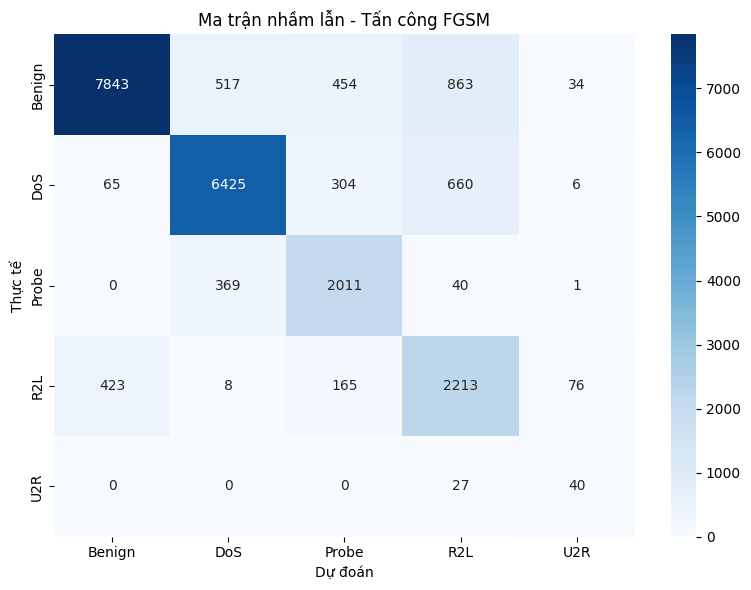


Độ chính xác tổng thể: 0.8220

TÓM TẮT KẾT QUẢ FGSM:
  - Epsilon: 0.005
  - Accuracy sau tấn công: 0.8220
  - Số mẫu test: 22544
Tham số FGSM:
  - Epsilon (độ lớn perturbation): 0.01
Đang thực hiện tấn công FGSM với epsilon=0.01

KẾT QUẢ ĐÁNH GIÁ - FGSM

BÁO CÁO PHÂN LOẠI:
              precision    recall  f1-score   support

      Benign     0.9417    0.8043    0.8676      9711
         DoS     0.8774    0.8605    0.8688      7460
       Probe     0.6810    0.8290    0.7478      2421
         R2L     0.5752    0.7633    0.6560      2885
         U2R     0.2532    0.5970    0.3556        67

    accuracy                         0.8197     22544
   macro avg     0.6657    0.7708    0.6992     22544
weighted avg     0.8435    0.8197    0.8265     22544



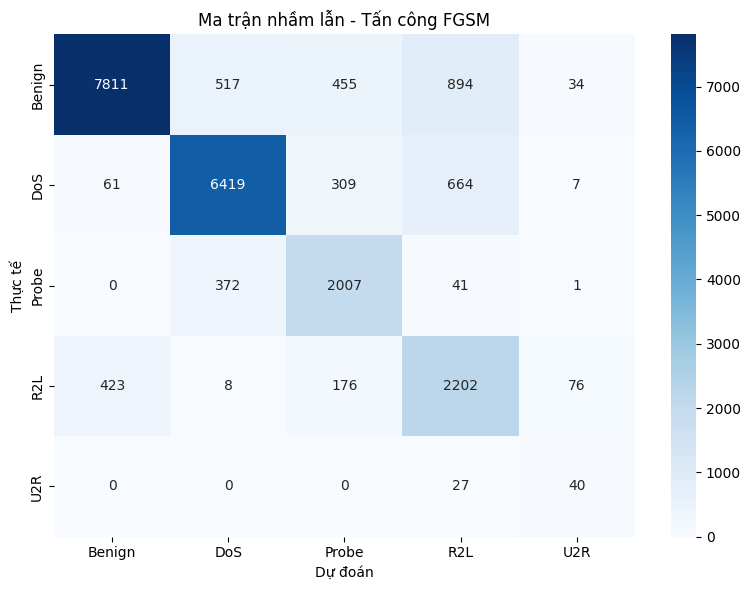


Độ chính xác tổng thể: 0.8197

TÓM TẮT KẾT QUẢ FGSM:
  - Epsilon: 0.01
  - Accuracy sau tấn công: 0.8197
  - Số mẫu test: 22544
Tham số FGSM:
  - Epsilon (độ lớn perturbation): 0.02
Đang thực hiện tấn công FGSM với epsilon=0.02

KẾT QUẢ ĐÁNH GIÁ - FGSM

BÁO CÁO PHÂN LOẠI:
              precision    recall  f1-score   support

      Benign     0.9410    0.7894    0.8586      9711
         DoS     0.8760    0.8583    0.8671      7460
       Probe     0.6757    0.8261    0.7434      2421
         R2L     0.5525    0.7605    0.6400      2885
         U2R     0.2548    0.5970    0.3571        67

    accuracy                         0.8119     22544
   macro avg     0.6600    0.7663    0.6932     22544
weighted avg     0.8392    0.8119    0.8195     22544



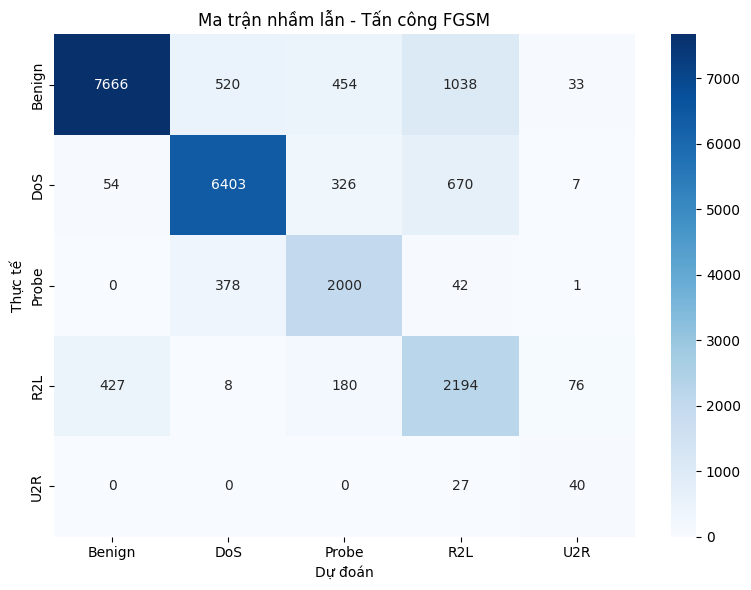


Độ chính xác tổng thể: 0.8119

TÓM TẮT KẾT QUẢ FGSM:
  - Epsilon: 0.02
  - Accuracy sau tấn công: 0.8119
  - Số mẫu test: 22544
Tham số FGSM:
  - Epsilon (độ lớn perturbation): 0.05
Đang thực hiện tấn công FGSM với epsilon=0.05

KẾT QUẢ ĐÁNH GIÁ - FGSM

BÁO CÁO PHÂN LOẠI:
              precision    recall  f1-score   support

      Benign     0.9240    0.7627    0.8357      9711
         DoS     0.8652    0.8034    0.8331      7460
       Probe     0.5896    0.8183    0.6853      2421
         R2L     0.4982    0.7047    0.5837      2885
         U2R     0.2500    0.5970    0.3524        67

    accuracy                         0.7742     22544
   macro avg     0.6254    0.7372    0.6581     22544
weighted avg     0.8121    0.7742    0.7850     22544



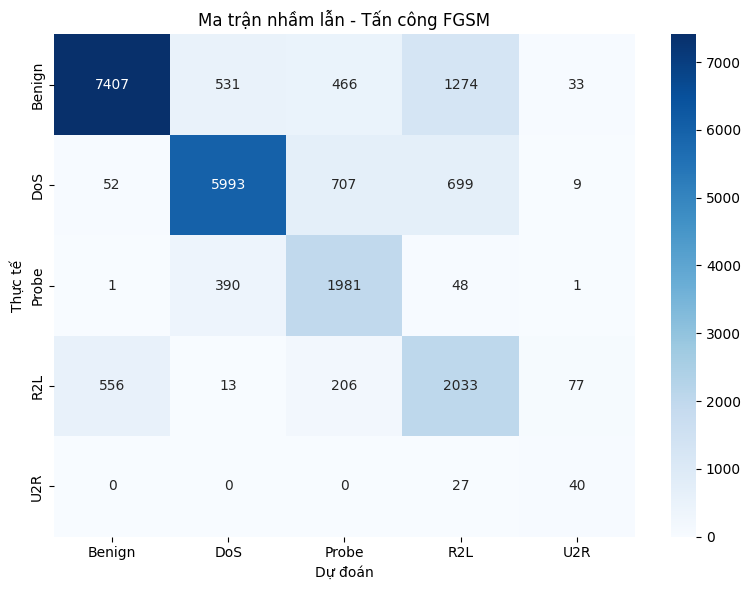


Độ chính xác tổng thể: 0.7742

TÓM TẮT KẾT QUẢ FGSM:
  - Epsilon: 0.05
  - Accuracy sau tấn công: 0.7742
  - Số mẫu test: 22544
Tham số FGSM:
  - Epsilon (độ lớn perturbation): 0.1
Đang thực hiện tấn công FGSM với epsilon=0.1

KẾT QUẢ ĐÁNH GIÁ - FGSM

BÁO CÁO PHÂN LOẠI:
              precision    recall  f1-score   support

      Benign     0.8746    0.7169    0.7880      9711
         DoS     0.8094    0.5693    0.6685      7460
       Probe     0.3962    0.7997    0.5298      2421
         R2L     0.4178    0.6135    0.4971      2885
         U2R     0.1776    0.5672    0.2705        67

    accuracy                         0.6633     22544
   macro avg     0.5351    0.6533    0.5508     22544
weighted avg     0.7411    0.6633    0.6819     22544



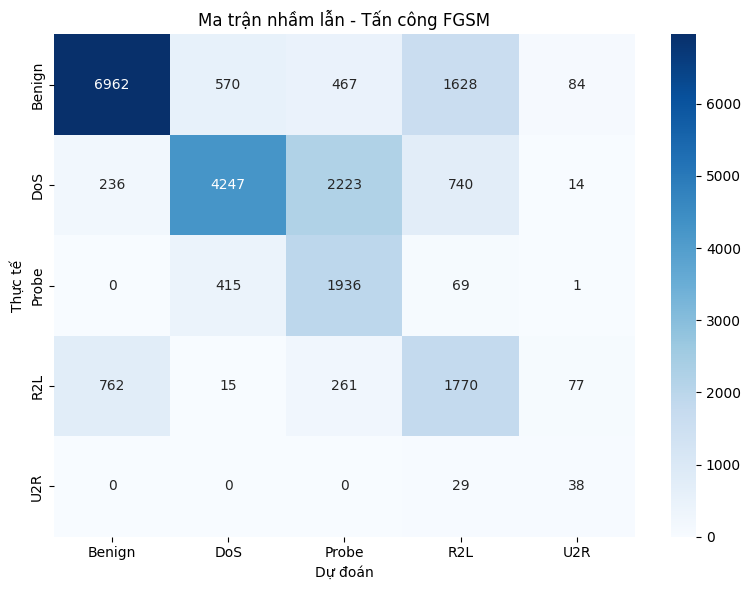


Độ chính xác tổng thể: 0.6633

TÓM TẮT KẾT QUẢ FGSM:
  - Epsilon: 0.1
  - Accuracy sau tấn công: 0.6633
  - Số mẫu test: 22544


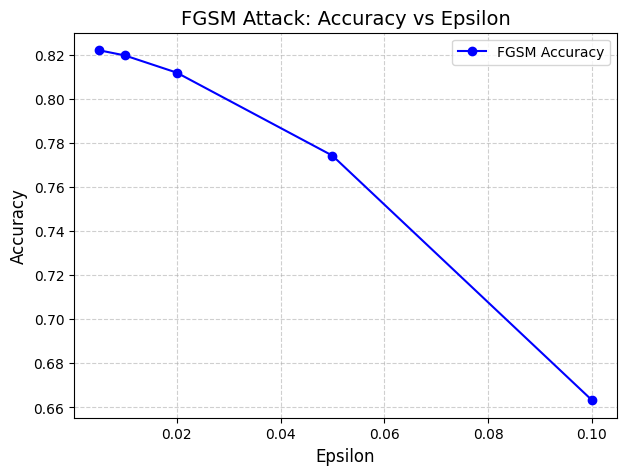

In [ ]:
# @title Đánh giá với tấn công FGSM + Vẽ biểu đồ
import matplotlib.pyplot as plt

print("="*60)
print("ĐÁNH GIÁ ROBUST DƯỚI TẤN CÔNG FGSM")
print("="*60)

epsilon = [0.005, 0.01, 0.02, 0.05, 0.1]
acc_list = []

# Sử dụng tham số FGSM đã định nghĩa
for i in epsilon:
    print(f"Tham số FGSM:")
    print(f"  - Epsilon (độ lớn perturbation): {i}")
    
    # Thực hiện tấn công FGSM
    yt_fgsm, yp_fgsm = eval_fgsm_attack(
        model, test_loader, 
        epsilon=i,
        mask=mask_1d, 
        bounds=bounds
    )
    
    # Hiển thị kết quả
    fgsm_accuracy = plot_attack_results(yt_fgsm, yp_fgsm, "FGSM", label_names)
    acc_list.append(fgsm_accuracy)
    
    print(f"\nTÓM TẮT KẾT QUẢ FGSM:")
    print(f"  - Epsilon: {i}")
    print(f"  - Accuracy sau tấn công: {fgsm_accuracy:.4f}")
    print(f"  - Số mẫu test: {len(yt_fgsm)}")
    print("="*60)

# Vẽ biểu đồ Accuracy vs Epsilon
plt.figure(figsize=(7,5))
plt.plot(epsilon, acc_list, marker='o', linestyle='-', color='b', label="FGSM Accuracy")
plt.xlabel("Epsilon", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("FGSM Attack: Accuracy vs Epsilon", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


ĐÁNH GIÁ ROBUST DƯỚI TẤN CÔNG PGD

Tham số PGD (eps1=0.01, eps2=0.00784313725490196):
  - Steps: 20
  - Alpha1: 0.0005
  - Alpha2: 0.000392156862745098

KẾT QUẢ ĐÁNH GIÁ - PGD (EPS1=0.01, EPS2=0.00784313725490196)

BÁO CÁO PHÂN LOẠI:
              precision    recall  f1-score   support

      Benign     0.9416    0.8052    0.8681      9711
         DoS     0.8770    0.8605    0.8687      7460
       Probe     0.6816    0.8286    0.7479      2421
         R2L     0.5764    0.7633    0.6568      2885
         U2R     0.2532    0.5970    0.3556        67

    accuracy                         0.8200     22544
   macro avg     0.6660    0.7709    0.6994     22544
weighted avg     0.8435    0.8200    0.8268     22544



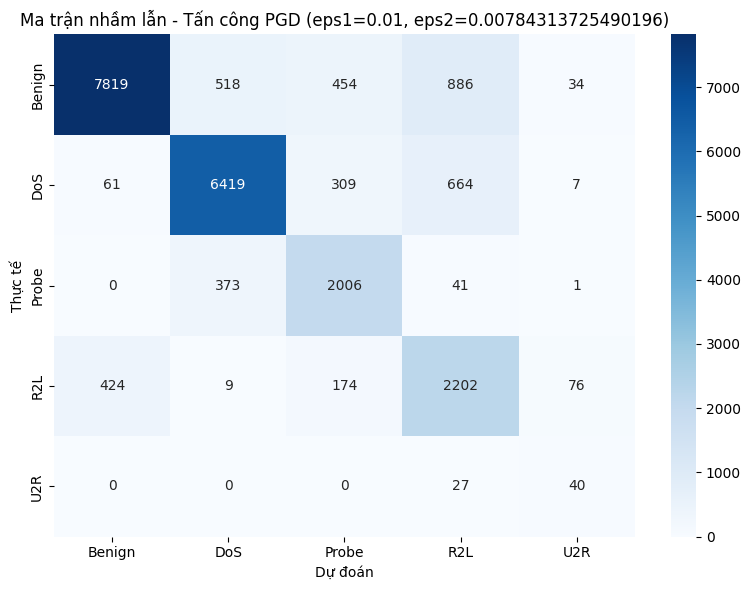


Độ chính xác tổng thể: 0.8200
Accuracy sau PGD attack: 0.8200

Tham số PGD (eps1=0.02, eps2=0.01568627450980392):
  - Steps: 20
  - Alpha1: 0.001
  - Alpha2: 0.000784313725490196

KẾT QUẢ ĐÁNH GIÁ - PGD (EPS1=0.02, EPS2=0.01568627450980392)

BÁO CÁO PHÂN LOẠI:
              precision    recall  f1-score   support

      Benign     0.9408    0.7909    0.8593      9711
         DoS     0.8756    0.8587    0.8671      7460
       Probe     0.6758    0.8265    0.7436      2421
         R2L     0.5549    0.7588    0.6410      2885
         U2R     0.2516    0.5970    0.3540        67

    accuracy                         0.8125     22544
   macro avg     0.6597    0.7664    0.6930     22544
weighted avg     0.8393    0.8125    0.8200     22544



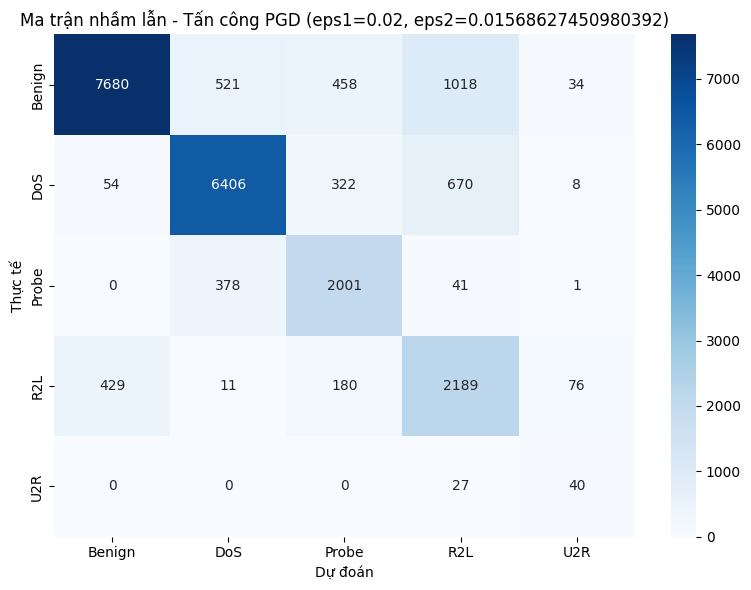


Độ chính xác tổng thể: 0.8125
Accuracy sau PGD attack: 0.8125

Tham số PGD (eps1=0.05, eps2=0.03137254901960784):
  - Steps: 20
  - Alpha1: 0.0025
  - Alpha2: 0.001568627450980392

KẾT QUẢ ĐÁNH GIÁ - PGD (EPS1=0.05, EPS2=0.03137254901960784)

BÁO CÁO PHÂN LOẠI:
              precision    recall  f1-score   support

      Benign     0.9158    0.7640    0.8330      9711
         DoS     0.8625    0.8027    0.8315      7460
       Probe     0.5829    0.8203    0.6815      2421
         R2L     0.4893    0.6669    0.5645      2885
         U2R     0.2484    0.5970    0.3509        67

    accuracy                         0.7699     22544
   macro avg     0.6198    0.7302    0.6523     22544
weighted avg     0.8058    0.7699    0.7805     22544



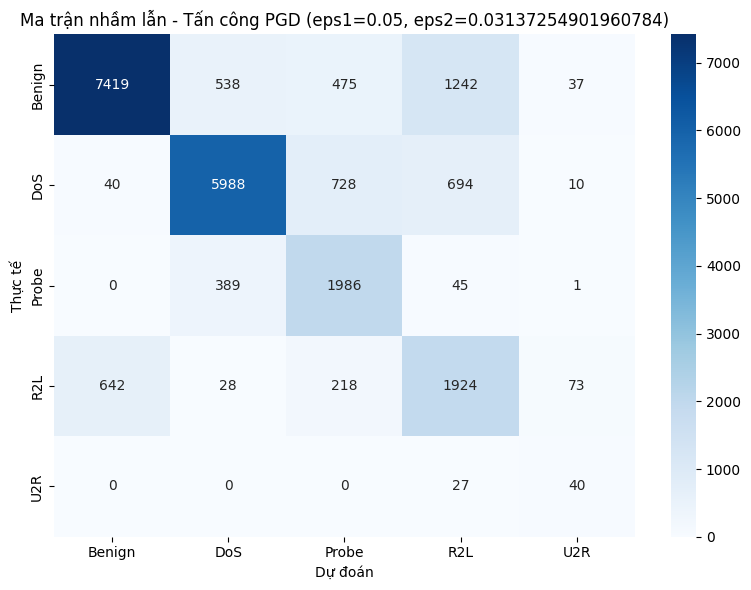


Độ chính xác tổng thể: 0.7699
Accuracy sau PGD attack: 0.7699


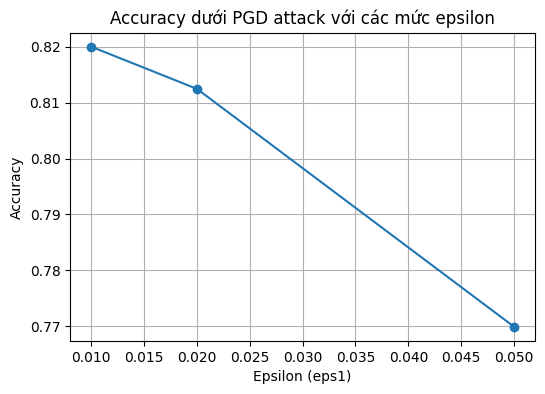

In [ ]:
import matplotlib.pyplot as plt

# @title Đánh giá với tấn công PGD + Vẽ biểu đồ acc vs epsilon
print("="*60)
print("ĐÁNH GIÁ ROBUST DƯỚI TẤN CÔNG PGD")
print("="*60)

# Danh sách epsilon để thử
epsilon_list = [
    {"eps1": 0.01, "eps2": 2/255.0, "steps": 20},   # nhẹ
    {"eps1": 0.02, "eps2": 4/255.0, "steps": 20},   # vừa
    {"eps1": 0.05, "eps2": 8/255.0, "steps": 20},   # mạnh
]

results = []  # lưu lại acc theo epsilon

for cfg in epsilon_list:
    pgd_eps1 = cfg["eps1"]
    pgd_eps2 = cfg["eps2"]
    pgd_steps = cfg["steps"]
    pgd_alpha1 = pgd_eps1 / pgd_steps   
    pgd_alpha2 = pgd_eps2 / pgd_steps

    print(f"\nTham số PGD (eps1={pgd_eps1}, eps2={pgd_eps2}):")
    print(f"  - Steps: {pgd_steps}")
    print(f"  - Alpha1: {pgd_alpha1}")
    print(f"  - Alpha2: {pgd_alpha2}")

    yt_pgd, yp_pgd = eval_pgd_attack(
        model, test_loader,
        epsilon1=pgd_eps1,
        epsilon2=pgd_eps2,
        alpha1=pgd_alpha1, 
        alpha2=pgd_alpha2,
        steps=pgd_steps,
        mask=mask_1d,
        bounds=bounds
    )

    pgd_accuracy = plot_attack_results(
        yt_pgd, yp_pgd, f"PGD (eps1={pgd_eps1}, eps2={pgd_eps2})", label_names
    )
    print(f"Accuracy sau PGD attack: {pgd_accuracy:.4f}")

    # Lưu kết quả
    results.append({
        "eps1": pgd_eps1,
        "eps2": pgd_eps2,
        "acc": pgd_accuracy
    })

print("="*60)

# Vẽ biểu đồ acc vs epsilon
eps_values = [r["eps1"] for r in results]   # hoặc dùng eps2 nếu muốn
acc_values = [r["acc"] for r in results]

plt.figure(figsize=(6,4))
plt.plot(eps_values, acc_values, marker="o", linestyle="-")
plt.xlabel("Epsilon (eps1)")
plt.ylabel("Accuracy")
plt.title("Accuracy dưới PGD attack với các mức epsilon")
plt.grid(True)
plt.show()


In [ ]:
import zipfile
import os
from IPython.display import FileLink

def zip_dir(directory = os.curdir, file_name = 'directory.zip'):
    """
    zip all the files in a directory
    
    Parameters
    _____
    directory: str
        directory needs to be zipped, defualt is current working directory
        
    file_name: str
        the name of the zipped file (including .zip), default is 'directory.zip'
        
    Returns
    _____
    Creates a hyperlink, which can be used to download the zip file)
    """
    os.chdir(directory)
    zip_ref = zipfile.ZipFile(file_name, mode='w')
    for folder, _, files in os.walk(directory):
        for file in files:
            if file_name in file:
                pass
            else:
                zip_ref.write(os.path.join(folder, file))

    return FileLink(file_name)
zip_dir()


/kaggle/working/directory.zip